In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

In [131]:
train_df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [132]:
train_df.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.000000,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,9261.500000,3.137764,5.265106,4.044319,7.996737,4.982097
std,5347.562529,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,3.000000,3.000000,5.000000,3.000000
50%,9261.500000,2.000000,5.000000,4.000000,8.000000,5.000000
75%,13892.250000,4.000000,8.000000,6.000000,12.000000,7.000000
max,18523.000000,11.000000,10.000000,7.000000,15.000000,10.000000


In [133]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [134]:
per = train_df[train_df['Stage_fear']== 'No']
per['Personality'].value_counts()

Personality
Extrovert    12314
Introvert      295
Name: count, dtype: int64

In [135]:
train_df['Personality'].value_counts()

Personality
Extrovert    13699
Introvert     4825
Name: count, dtype: int64

In [136]:
train_df.columns

Index(['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [3]:
num_col = ['Time_spent_Alone', 'Social_event_attendance','Going_outside', 'Friends_circle_size','Post_frequency']
cat_col = ['Stage_fear','Drained_after_socializing']

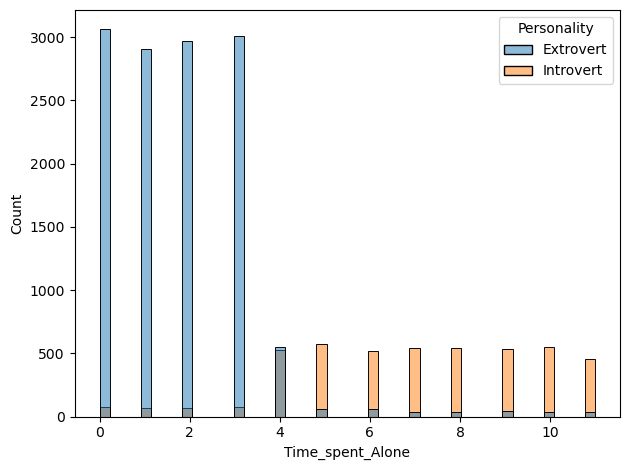

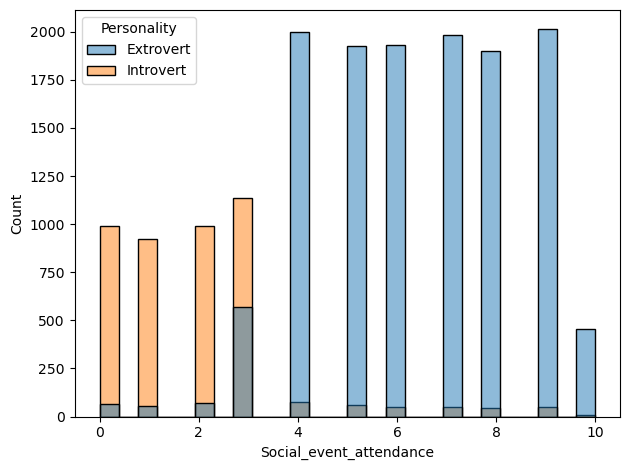

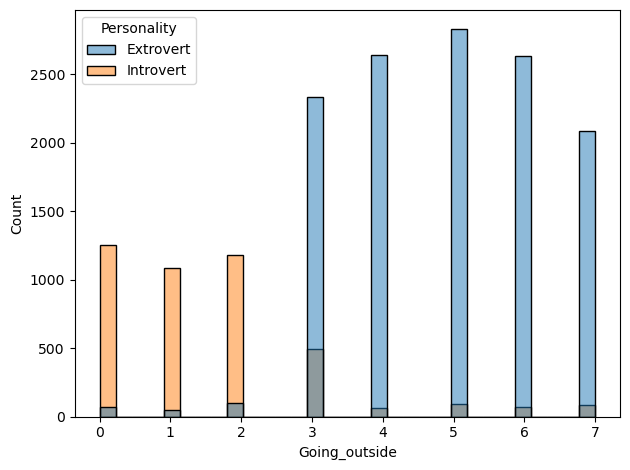

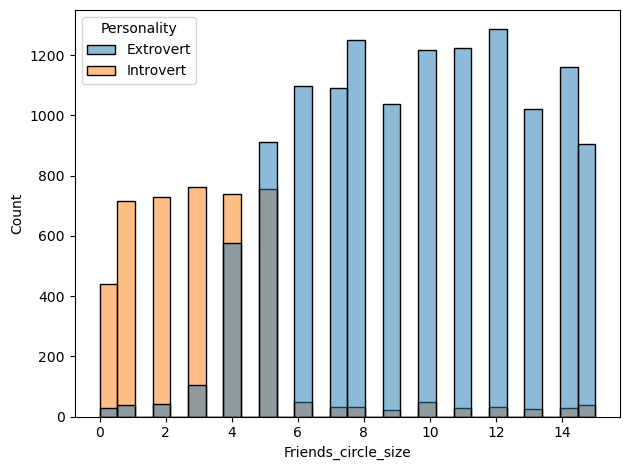

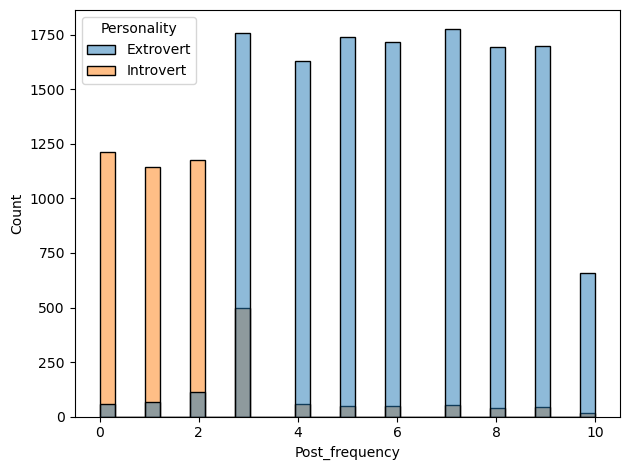

In [138]:
for col in num_col:
    sns.histplot(data=train_df,x=col, hue='Personality') 
    plt.tight_layout()
    plt.show()

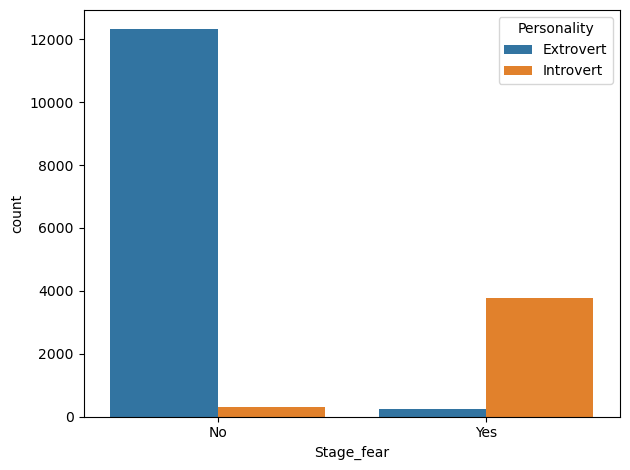

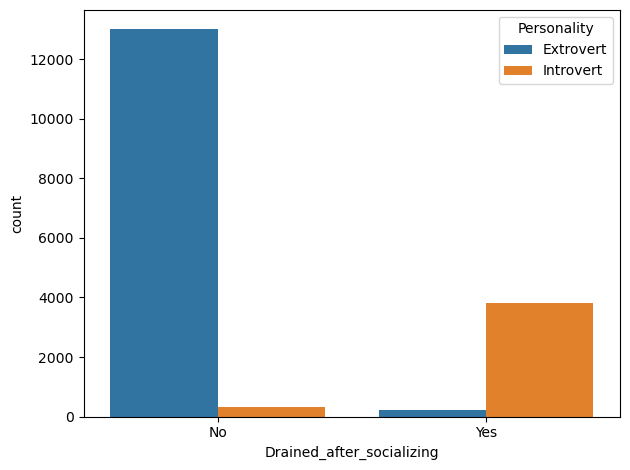

In [139]:
for columns in cat_col:
    sns.countplot(data=train_df, x=columns, hue='Personality')
    plt.tight_layout()
    plt.show()

We seen from the distribution on the categorical and numerical colums the imbance in the dataset 
let compare the numerical features across the label 

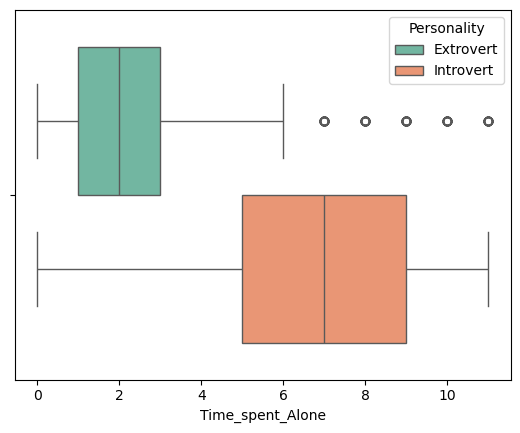

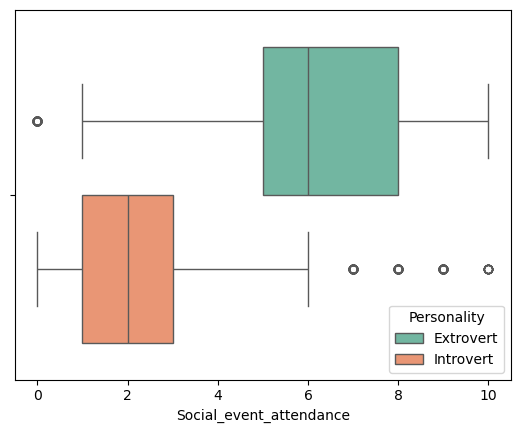

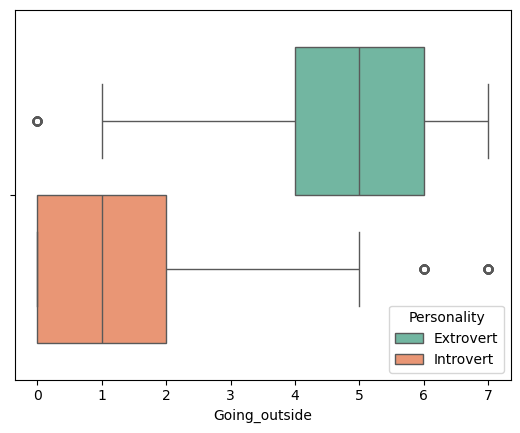

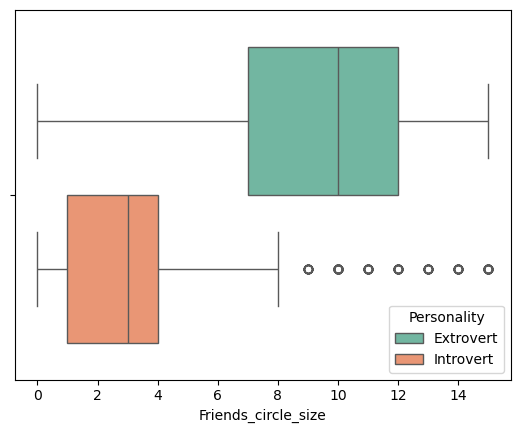

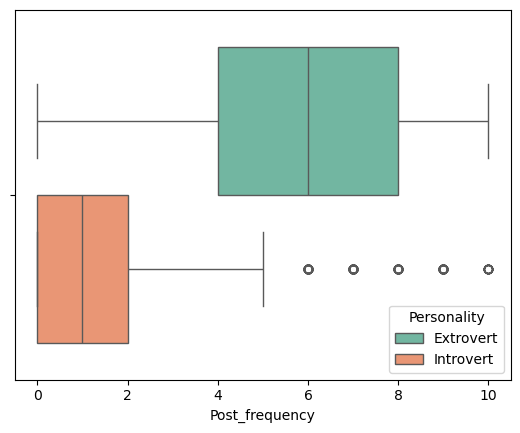

In [140]:
for columns in num_col:
    sns.boxplot(data=train_df, x=columns, hue='Personality',palette='Set2')
    plt.show()

In [141]:
# shows the average of pople with stage fear in each category
train_df.groupby('Personality')['Social_event_attendance'].mean()

Personality
Extrovert    6.389450
Introvert    1.934202
Name: Social_event_attendance, dtype: float64

In [142]:
train_df[train_df['Drained_after_socializing'] == 'Yes']['Personality'].value_counts()

Personality
Introvert    3826
Extrovert     236
Name: count, dtype: int64

In [143]:
per = train_df[train_df['Stage_fear']== 'Yes']
per['Personality'].value_counts()

Personality
Introvert    3786
Extrovert     236
Name: count, dtype: int64

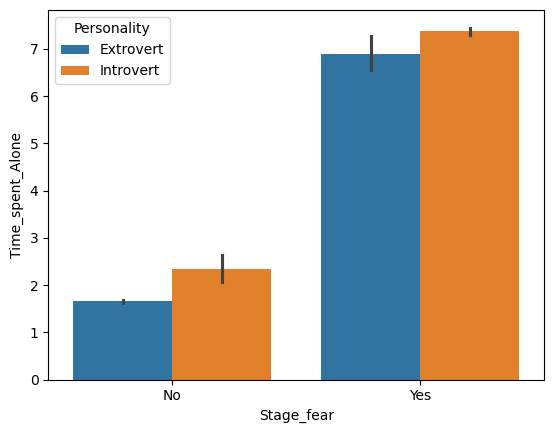

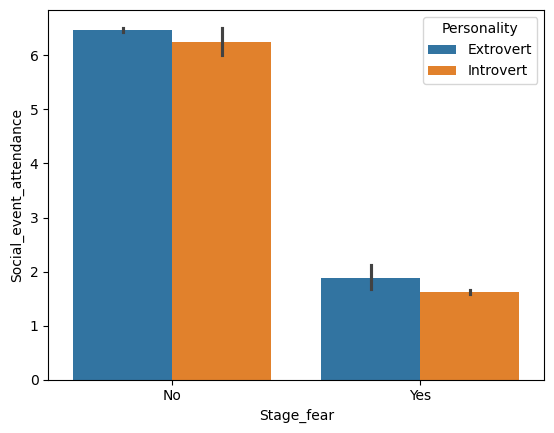

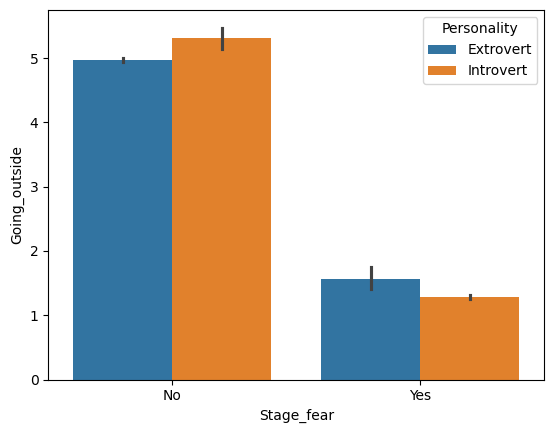

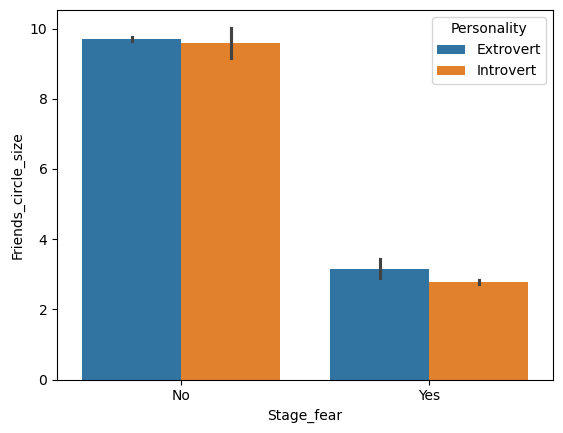

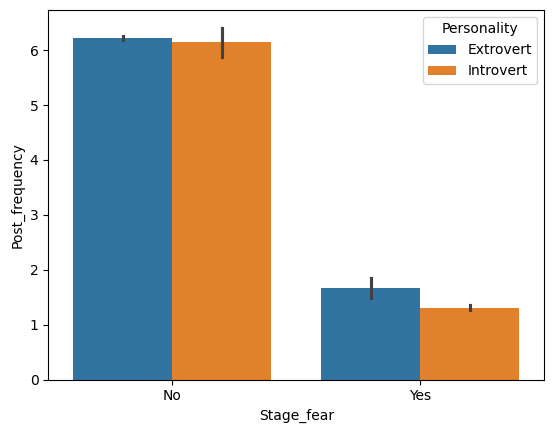

In [144]:
for col in num_col:
    sns.barplot(data=train_df, x='Stage_fear', y=col, hue='Personality' )
    plt.show()

<Axes: >

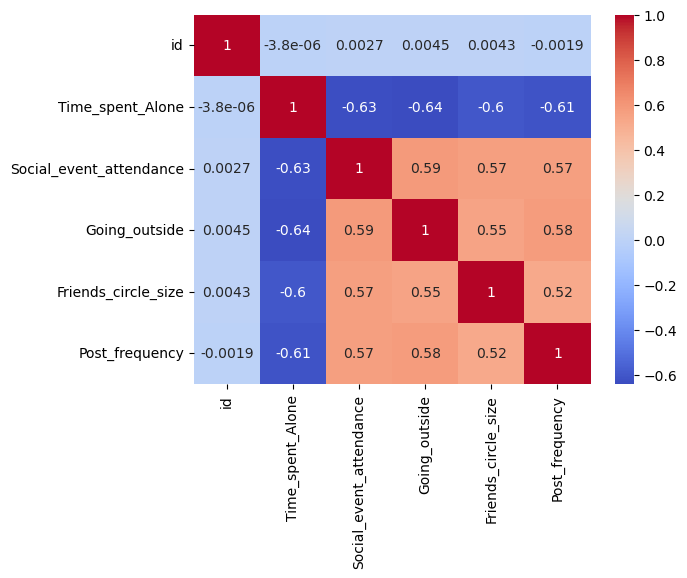

In [145]:
numerical_cols = train_df.select_dtypes(include=[np.number]).columns
corr_matrix = train_df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [35]:
train_df.isnull().sum()

Time_spent_Alone           0
Stage_fear                 0
Social_event_attendance    0
Going_outside              0
Friends_circle_size        0
Post_frequency             0
dtype: int64

In [ ]:
test_df.isnull().sum()

In [5]:
train_df = train_df.drop(columns=['Drained_after_socializing','id']) # drop unwanted columns
train_df['Stage_fear'] = train_df['Stage_fear'].fillna(train_df['Stage_fear'].mode()[0]) #fill Stage_fear with the most class present

for col in num_col:
    train_df[col] = train_df[col].fillna(train_df.groupby('Stage_fear')[col].transform('mean'))
    #fill numerical columns after groupby a field that has a decent distribution of each class

In [6]:
test_df = test_df.drop(columns=['Drained_after_socializing','id'])
test_df['Stage_fear'] = test_df['Stage_fear'].fillna(test_df['Stage_fear'].mode()[0])

for col in num_col:
    test_df[col] = test_df[col].fillna(test_df.groupby('Stage_fear')[col].transform('mean'))

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder1 = LabelEncoder()
encoder2 = LabelEncoder()

In [8]:
train_df['Stage_fear']  = encoder1.fit_transform(train_df['Stage_fear'])
test_df['Stage_fear'] = encoder1.transform(test_df['Stage_fear'])

In [9]:
train_df['Personality'] = encoder2.fit_transform(train_df['Personality'])

In [39]:
train_df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
0,0.0,0,6.0,4.0,15.0,5.000000
1,1.0,0,7.0,3.0,10.0,8.000000
2,6.0,1,1.0,0.0,3.0,0.000000
3,3.0,0,7.0,3.0,11.0,5.000000
4,1.0,0,4.0,4.0,13.0,5.927561


In [37]:
import joblib

joblib.dump(encoder1,'Stage_fear_le.pkl')
joblib.dump(encoder2,'Personality_le.pkl')

['Personality_le.pkl']

In [10]:
y = train_df.pop('Personality')
X = train_df

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, 
                                                  random_state=42, 
                                                  stratify=y) # the stratify is important because of the imbalance class

In [12]:
X_train.shape

(14819, 6)

In [ ]:
from xgboost import XGBClassifier 

model = XGBClassifier()

In [ ]:
model.fit(X_train,y_train,)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix
y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f'accuracy:{accuracy:.4f}')
print(accuracy)

accuracy:0.9706
0.9705802968960864


In [16]:
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2740
           1       0.94      0.95      0.94       965

    accuracy                           0.97      3705
   macro avg       0.96      0.96      0.96      3705
weighted avg       0.97      0.97      0.97      3705

[[2682   58]
 [  51  914]]


In [ ]:
# For your 3:1 imbalance, try different values
values =[3,2,4,5]
for val in values:
    model = XGBClassifier(scale_pos_weight=val)  
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    precision = precision_score(y_val, y_pred)
    print(f'precision for value{val}: {precision:.4f}')

precision for value3: 0.9309
precision for value2: 0.9385
precision for value4: 0.9291
precision for value5: 0.9225


In [19]:
param = {
    'max_depth': 5,
    'learning_rate': 0.05,
    'gamma': 0.2,
    'scale_pos_weight': 0.9 #cause lower scale_pos_weight have better precision
}

In [ ]:
model = XGBClassifier(**param) 
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [21]:
y_pred = model.predict(X_val)

precision = precision_score(y_val, y_pred)
print(f'precision:{precision:.4f}')

precision:0.9415


In [22]:
y_proba = model.predict_proba(X_val)[:, 1]  # Probabilities for positive class
y_proba

array([0.96649283, 0.955326  , 0.95604265, ..., 0.01734987, 0.92289114,
       0.0132886 ], dtype=float32)

In [23]:
from sklearn.metrics import precision_recall_curve
#  precision at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba) 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


In [ ]:
report_dict = classification_report( y_val,y_pred, output_dict=True)
report_dict

In [38]:
joblib.dump(model,'model.pkl')

['model.pkl']

### Working with ML flow for Experiment Tracking

In [30]:
import mlflow 

mlflow.set_experiment('my first experiment')
mlflow.set_tracking_uri('http://127.0.0.1:5000')

2025/07/17 13:13:40 INFO mlflow.tracking.fluent: Experiment with name 'my first experiment' does not exist. Creating a new experiment.


In [34]:
with mlflow.start_run():
    mlflow.log_params(param)
    mlflow.log_metrics({
        'accuracy': report_dict['accuracy'],
        'recall_for_class_0': report_dict['0']['recall'],
        'recall_for_class_1': report_dict['1']['recall'],
        'fl_score': report_dict['macro avg']['f1-score']
        }
    )
    mlflow.sklearn.log_model(model, 'XGBClassifier')

2025/07/17 13:16:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/17 13:18:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run capable-shrike-270 at: http://127.0.0.1:5000/#/experiments/646345550385347865/runs/226a674deda6452caeabed60e4b5717c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/646345550385347865


In [217]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

# Find the threshold that gives you closest to 94% precision
target_precision = 0.94
idx = np.argmin(np.abs(precisions - target_precision))
optimal_threshold = thresholds[idx]
achieved_precision = precisions[idx]
corresponding_recall = recalls[idx]

print(f"Threshold: {optimal_threshold:.3f}")
print(f"Precision: {achieved_precision:.3f}")
print(f"Recall: {corresponding_recall:.3f}")

Threshold: 0.940
Precision: 0.940
Recall: 0.731


In [218]:
# Instead of model.predict(X_val), use:
y_pred_custom = (y_proba >= optimal_threshold).astype(int)